In [2]:
import os
import pandas as pd
from dotenv import load_dotenv
from supabase import create_client, Client
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
load_dotenv()
url = os.environ.get("SUPABASE_URL").strip()
key = os.environ.get("SUPABASE_KEY").strip()

In [4]:
supabase: Client = create_client(url, key)
response = supabase.table('matches').select('*').limit(10000).execute()
df_models = pd.DataFrame(response.data)

print(f"success: downloaded {len(df_models)} records")

success: downloaded 8445 records


In [5]:
df_models = df_models.sort_values('date').reset_index(drop=True)

In [6]:
features = [
    'b365h', 'b365d', 'b365a',
    'home_team_goals_avg_last_5', 'away_goals_avg_last_5', 
    'home_goals_conceded_avg_last_5', 'away_goals_conceded_avg_last_5',
    'ht_home_goals_avg_last_5', 'ht_away_goals_avg_last_5',
    'home_form_1h_last_5', 'away_form_1h_last_5', 'home_form_2h_last_5', 'away_form_2h_last_5',
    'home_shots_avg_last_5', 'away_shots_avg_last_5', 
    'home_shots_target_avg_last_5', 'away_shots_target_avg_last_5',
    'home_red_cards_avg_last_5', 'away_red_cards_avg_last_5',
    'home_points_avg_last_5', 'away_points_avg_last_5', 
    'home_overall_points_last_5', 'away_overall_points_last_5'
]



In [7]:
missing_values = df_models.isnull().mean() * 100
missing_values[missing_values > 0]

home_team_goals_avg_last_5        1.539372
away_goals_avg_last_5             1.539372
ht_home_goals_avg_last_5          1.539372
ht_away_goals_avg_last_5          1.539372
home_form_1h_last_5               1.539372
away_form_1h_last_5               1.539372
home_form_2h_last_5               1.539372
away_form_2h_last_5               1.539372
home_shots_avg_last_5             1.539372
away_shots_avg_last_5             1.539372
home_shots_target_avg_last_5      1.539372
away_shots_target_avg_last_5      1.539372
home_red_cards_avg_last_5         1.539372
away_red_cards_avg_last_5         1.539372
home_goals_conceded_avg_last_5    1.539372
away_goals_conceded_avg_last_5    1.539372
home_points_avg_last_5            1.539372
away_points_avg_last_5            1.539372
home_overall_points_last_5        0.746004
away_overall_points_last_5        0.793369
dtype: float64

In [8]:
df_clean_for_ml = df_models.dropna(subset=features + ['target'])

In [9]:
X = df_clean_for_ml[features].astype(float)
y = df_clean_for_ml['target'].astype(int)
df_clean_for_ml.to_csv('../data/cleaned_historical_data.csv', index=False)
split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]  
y_test = y.iloc[split_index:]

In [10]:
tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')


param_grid = {
    'n_estimators': [50, 100, 200],      
    'max_depth': [3, 5, 7],              
    'learning_rate': [0.01, 0.1]         
}

print("Starting GridSearchCV for XGBoost")


grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,                     
    scoring='accuracy',          
    n_jobs=-1,                    
    verbose=1                     
)

grid_search.fit(X_train, y_train)

best_xgb_model = grid_search.best_estimator_
predictions = best_xgb_model.predict(X_test)
final_accuracy = accuracy_score(y_test, predictions)

print(f"best params: {grid_search.best_params_}")
print(f"Hold-out Test Accuracy: {final_accuracy * 100:.2f}%")
print("="*45)

best_xgb_model = grid_search.best_estimator_

Starting GridSearchCV for XGBoost
Fitting 3 folds for each of 18 candidates, totalling 54 fits
best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Hold-out Test Accuracy: 54.11%


In [11]:
rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [5, 10, None],      
    'min_samples_split': [2, 5, 10] 
}

rf_grid_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

best_rf_model = rf_grid_search.best_estimator_
rf_predictions = rf_grid_search.predict(X_test)

print(f"Best RF params: {rf_grid_search.best_params_}")
print(f"RF Hold-out Test Accuracy: {accuracy_score(y_test, rf_predictions) * 100:.2f}%")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best RF params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
RF Hold-out Test Accuracy: 54.35%


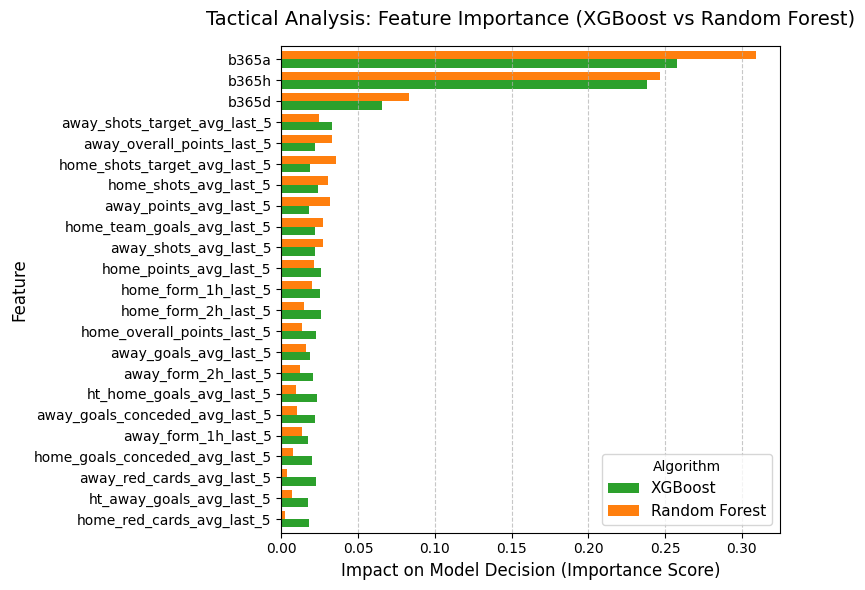

In [12]:
xgb_importances = best_xgb_model.feature_importances_
rf_importances = best_rf_model.feature_importances_


df_imp = pd.DataFrame({
    'Feature': features,
    'XGBoost': xgb_importances,
    'Random Forest': rf_importances
})


df_imp['Mean_Importance'] = df_imp[['XGBoost', 'Random Forest']].mean(axis=1)
df_imp = df_imp.sort_values(by='Mean_Importance', ascending=True).drop(columns='Mean_Importance')

ax = df_imp.set_index('Feature').plot(
    kind='barh', 
    figsize=(8, 6), 
    color=['#2ca02c', '#ff7f0e'], 
    width=0.8
)

plt.title('Tactical Analysis: Feature Importance (XGBoost vs Random Forest)', fontsize=14, pad=15)
plt.xlabel('Impact on Model Decision (Importance Score)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.legend(title='Algorithm', loc='lower right', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

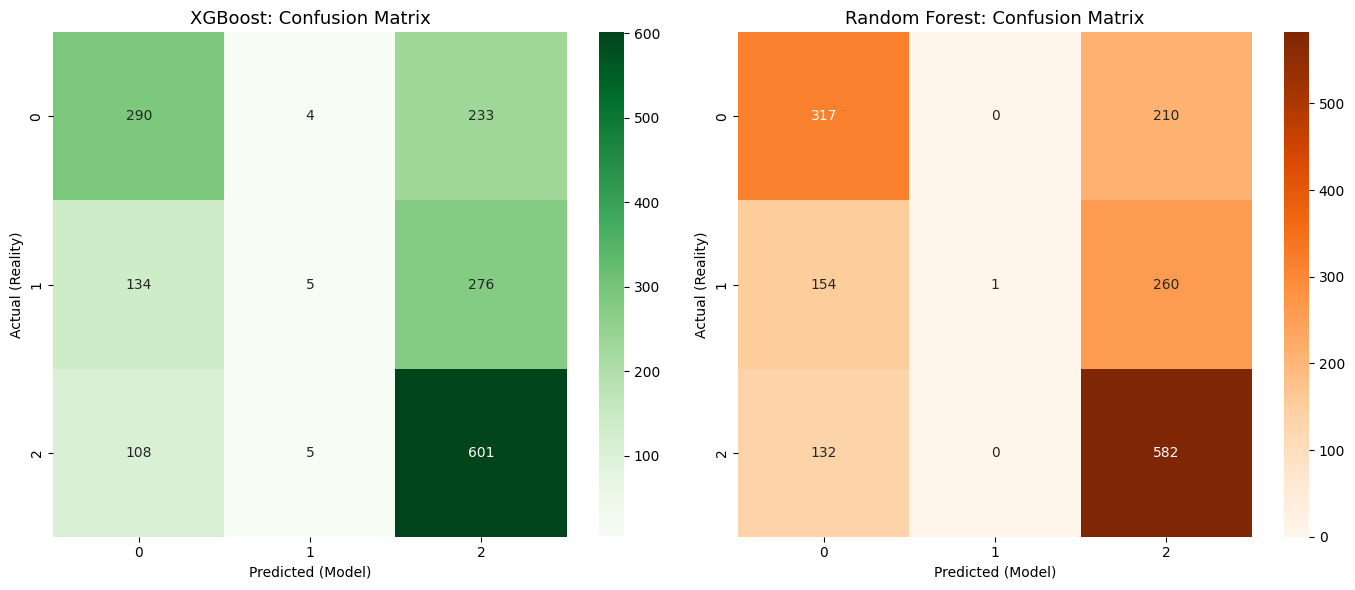

In [13]:
from sklearn.metrics import confusion_matrix


y_pred_xgb = best_xgb_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)


classes = best_xgb_model.classes_


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=classes)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax1,
            xticklabels=classes, yticklabels=classes)
ax1.set_title('XGBoost: Confusion Matrix', fontsize=13)
ax1.set_xlabel('Predicted (Model)')
ax1.set_ylabel('Actual (Reality)')


cm_rf = confusion_matrix(y_test, y_pred_rf, labels=classes)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=classes, yticklabels=classes)
ax2.set_title('Random Forest: Confusion Matrix', fontsize=13)
ax2.set_xlabel('Predicted (Model)')
ax2.set_ylabel('Actual (Reality)')

plt.tight_layout()
plt.show()

In [14]:
xgb_probs = best_xgb_model.predict_proba(X_test)

xgb_max_probs = np.max(xgb_probs, axis=1)
xgb_preds = best_xgb_model.predict(X_test)

analysis_df = pd.DataFrame({
    'Actual_Result': y_test,
    'Predicted_Result': xgb_preds,
    'Confidence_Score': xgb_max_probs
})

confidence_threshold = 0.65
expert_picks = analysis_df[analysis_df['Confidence_Score'] >= confidence_threshold]

print(f"Standard Accuracy (All matches): {accuracy_score(y_test, xgb_preds)*100:.2f}%")

if len(expert_picks) > 0:
    expert_acc = accuracy_score(expert_picks['Actual_Result'], expert_picks['Predicted_Result'])
    print(f"Expert Accuracy (Confidence > {confidence_threshold*100}%): {expert_acc*100:.2f}%")
    print(f"Number of 'Expert' matches found: {len(expert_picks)} out of {len(analysis_df)}")
else:
    print(f"No matches found with confidence above {confidence_threshold*100}%. Try lowering the threshold.")

Standard Accuracy (All matches): 54.11%
Expert Accuracy (Confidence > 65.0%): 81.25%
Number of 'Expert' matches found: 240 out of 1656


In [15]:
import joblib
import os


if not os.path.exists('../models'):
    os.makedirs('../models')

final_xgb_model = best_xgb_model
final_rf_model = best_rf_model


xgb_path = '../models/xgboost_betting_model.pkl'
rf_path = '../models/random_forest_betting_model.pkl'
features_path = '../models/model_features.pkl'


joblib.dump(final_xgb_model, xgb_path)
joblib.dump(final_rf_model, rf_path)
joblib.dump(features, features_path)

print(f"XGBoost saved to: {xgb_path}")
print(f"Random Forest saved to: {rf_path}")
print(f"Features list saved to: {features_path}")

XGBoost saved to: ../models/xgboost_betting_model.pkl
Random Forest saved to: ../models/random_forest_betting_model.pkl
Features list saved to: ../models/model_features.pkl
